Cluster Hierarquico

O agrupamento hierárquico é uma técnica de aprendizado de máquina não supervisionado que visa agrupar dados em uma estrutura de árvore de clusters aninhados. Existem dois principais tipos de agrupamento hierárquico: aglomerativo, que combina clusters menores em clusters maiores, e divisivo, que divide um cluster grande em clusters menores. Essa técnica é útil para encontrar padrões e conexões em conjuntos de dados

Bibliotecas Utilizadas

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
import numpy as np
import scipy as sp
from scipy import stats as st
from scipy.spatial import distance_matrix
from scipy.spatial import distance
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels as stm
from sklearn.model_selection import train_test_split

Dados

Foi carregado o conjunto de dados de um arquivo Excel para um DataFrame do pandas chamado df. Este DataFrame é a estrutura central que armazenará todos os indicadores dos municípios, permitindo que o Python os manipule e analise de forma eficiente

In [48]:
df = pd.read_csv("/content/matriz_risco_fundos (1).csv", encoding='latin1')

Foi criada uma lista chamada variaveis que contém os nomes de todas as colunas (indicadores) que serão utilizadas para formar os grupos. Selecionar apenas as variáveis relevantes é um passo crucial, pois são elas que definirão os critérios de semelhança entre os municípios.

In [49]:
variaveis = ['RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']

Nesta célula, adotamos uma estratégia para tratar os valores ausentes chamada imputação. Diferente de remover as linhas (dropna), este método preserva os dados.

O código percorre cada uma das colunas selecionadas na lista variaveis. Para cada coluna, ele substitui todos os valores ausentes (NaN) pela média (mean) da própria coluna. Essa técnica nos permite manter o máximo de registros possível no nosso conjunto de dados, preenchendo as lacunas com um valor central e representativo daquela variável.


In [50]:
for col in variaveis:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

df = df.copy()

Foram contados a quantidade exata de valores ausentes em cada uma das colunas selecionadas para a análise.

In [51]:
df[variaveis].isna().sum()

,0
RETORNO_MEDIO_DIARIO,0
VOLATILIDADE_RISCO,0


Extraimos uma amostra aleatória e representativa de 100 registros do nosso conjunto de dados para ser utilizada em visualizações, como o dendrograma.


In [52]:
X = df[variaveis]
X_amostra, _, _, _ = train_test_split(X, X, train_size=100, random_state=42)

Realizamos a padronização desses dados. Este é um pré-processamento indispensável para algoritmos baseados em distância, como a clusterização hierárquica que será usada para gerar o dendrograma.A padronização é necessária para que todas as variáveis tenham a mesma importância na análise.

In [53]:
z_variaveis = [ 'Z_' + var for var in variaveis ]
scaler = StandardScaler()
df_padronizado = pd.DataFrame(scaler.fit_transform(X_amostra), columns=z_variaveis)

Padronização Z-Score.

In [54]:
scaler = StandardScaler()
df_padronizado = scaler.fit_transform(X_amostra)
df_padronizado = pd.DataFrame(df_padronizado, columns=z_variaveis)

Outiliers

criamos uma visualização que nos permita identificar a presença de outliers em cada uma das nossas variáveis de forma individual (análise univariada). Para isso, utilizamos o gráfico de Boxplot, que é uma ferramenta estatística poderosa para mostrar a distribuição dos dados e destacar valores atípicos.

(-3.0, 3.0)

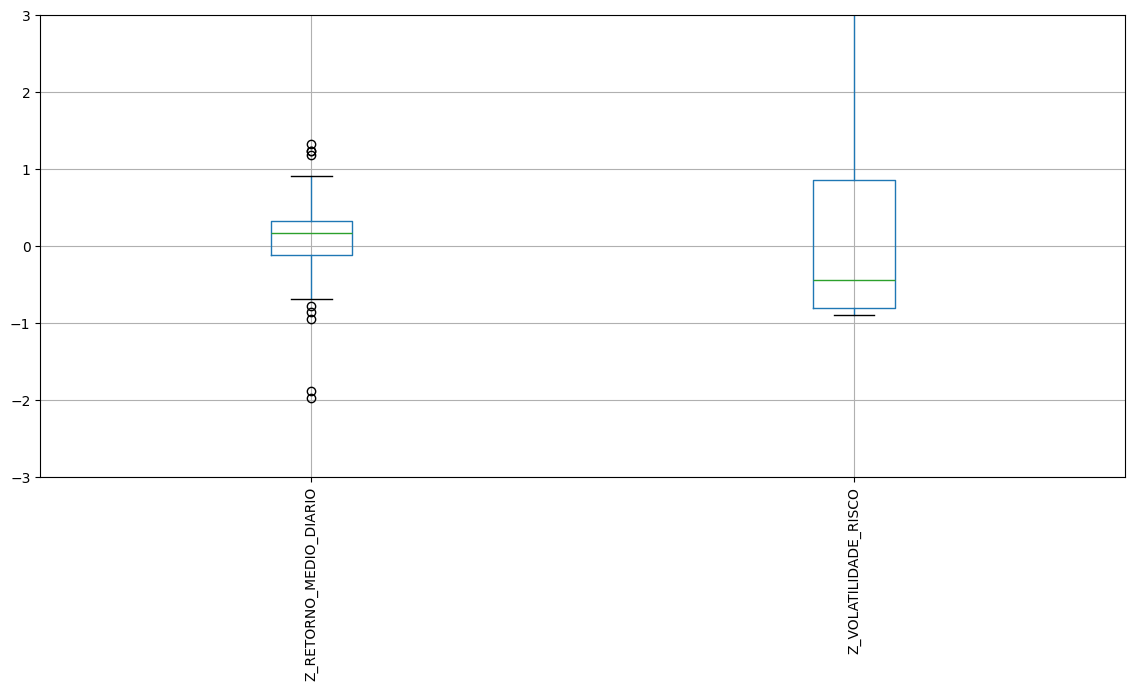

In [55]:
df_padronizado[z_variaveis].boxplot(rot=90,figsize=[14,6])
plt.ylim(-3,3)

....

In [56]:
def mahalanobis(x=None, data=None, cov=None):
    """Computa a Distância de Mahalanobis entre cada objeto e a média
    x    : vetor ou matriz de dados, com p colunas.
    data : ndarray dos dados a partir do qual a a Distância de Mahalanobis para cada observação de x deve ser computado.
    cov  : Matriz de covariancia (p x p) dos dados. Se None, ela será calculada a partir dos dados.
    """
    x_minus_mu = x - np.mean(data)
    if not cov:
        cov = np.cov(data.values.T)
    inv_covmat = sp.linalg.inv(cov)
    left_term = np.dot(x_minus_mu, inv_covmat)
    mahal = np.dot(left_term, x_minus_mu.T)
    return mahal.diagonal()

In [57]:
df_padronizado['mahala'] = mahalanobis(x=df_padronizado[z_variaveis], data=df_padronizado[z_variaveis])

In [58]:
df_padronizado.head()

,Z_RETORNO_MEDIO_DIARIO,Z_VOLATILIDADE_RISCO,mahala
0,-0.112204,1.201044,1.510530
1,1.236901,0.238346,1.960195
2,-1.970762,2.561649,7.952306
3,0.301146,-0.859012,0.731235
4,0.284338,-0.735361,0.537922


Para encontrar outlier vamos multiplicar 2,5*2 variaveis = 5. Logo, observaçõs com distância de mahalanobis maior que 5, representam outliers multivariados.


In [59]:
outlier = df_padronizado.loc[df_padronizado['mahala'] > 5]
outlier

,Z_RETORNO_MEDIO_DIARIO,Z_VOLATILIDADE_RISCO,mahala
2,-1.970762,2.561649,7.952306
36,3.163539,2.158817,21.028962
53,-4.507817,2.142154,20.650645
68,-4.786219,3.233642,25.858554
71,0.889738,2.189927,7.547526
99,-4.546911,2.126306,20.958409


Observações: Fundos 2,36,53,68,71 e 99

In [60]:
indices_outliers = outlier.index


df_limpo = df_padronizado.drop(indices_outliers)


print(f"DataFrame original tinha {len(df_padronizado)} linhas.")
print(f"DataFrame limpo tem {len(df_limpo)} linhas.")

DataFrame original tinha 100 linhas.
DataFrame limpo tem 94 linhas.


limpeza efetuada

(-3.0, 3.0)

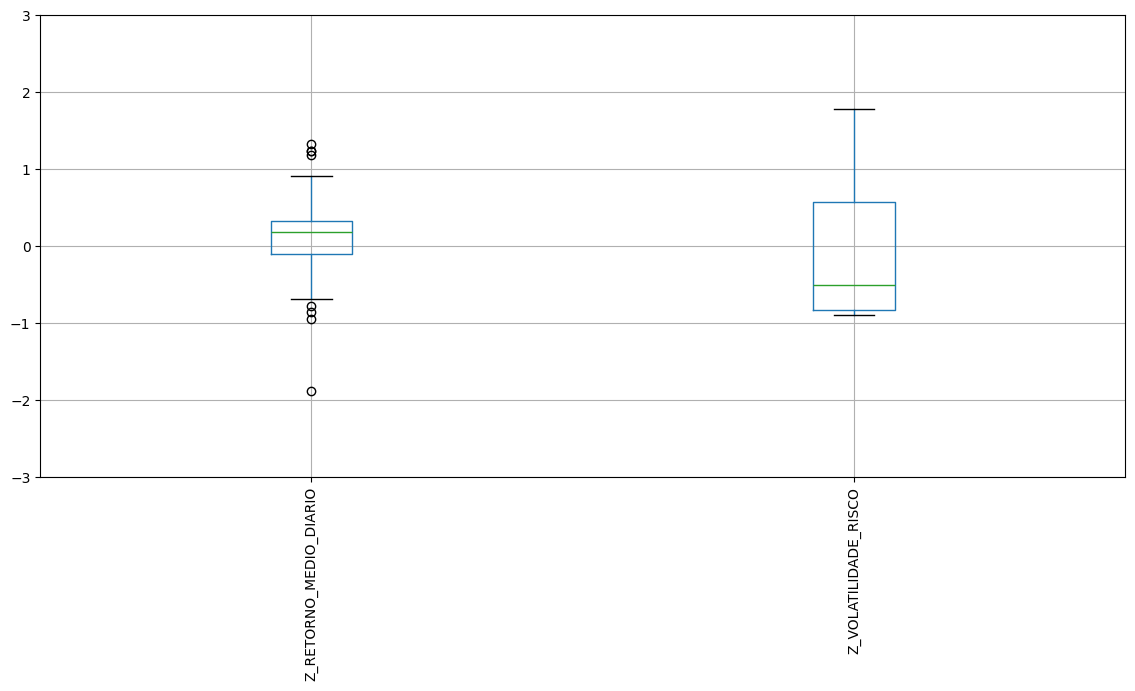

In [61]:
df_limpo[z_variaveis].boxplot(rot=90,figsize=[14,6])
plt.ylim(-3,3)

MÉTODOS DE AFGRUPAMENTO HIERARQUICOS


In [62]:
Z = linkage(df_limpo, method='ward', metric='euclidean')

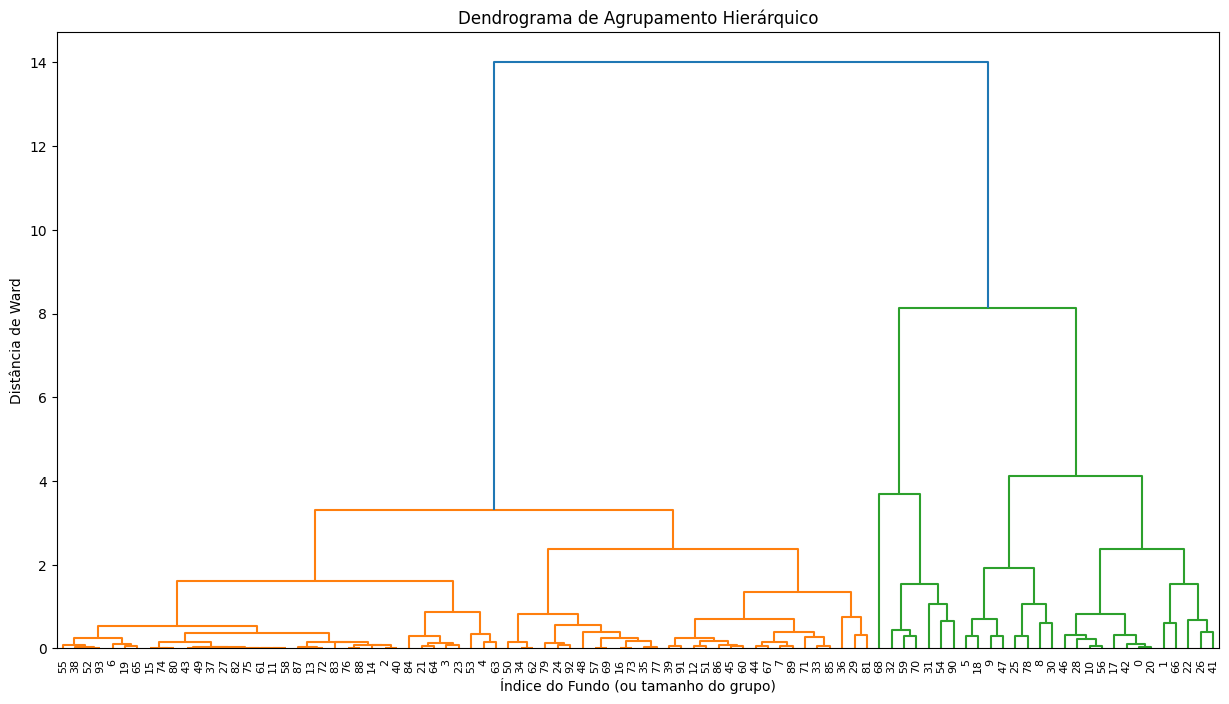

In [63]:
plt.figure(figsize=(15, 8))
plt.title('Dendrograma de Agrupamento Hierárquico')
plt.xlabel('Índice do Fundo (ou tamanho do grupo)')
plt.ylabel('Distância de Ward')

# Cria o gráfico a partir da sua matriz Z
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)

plt.show()

Aqui podemos ver melhor a melhor formação parece ser (K=3)

In [64]:
print ('Planejamento da Aglomeração\n')
print(Z)

Planejamento da Aglomeração

[[1.10000000e+01 5.80000000e+01 2.01255389e-03 2.00000000e+00]
 [6.10000000e+01 9.40000000e+01 4.44067694e-03 3.00000000e+00]
 [4.30000000e+01 4.90000000e+01 4.70615639e-03 2.00000000e+00]
 [2.70000000e+01 8.20000000e+01 4.75492493e-03 2.00000000e+00]
 [7.60000000e+01 8.80000000e+01 5.52656163e-03 2.00000000e+00]
 [7.40000000e+01 8.00000000e+01 7.81761917e-03 2.00000000e+00]
 [7.50000000e+01 9.50000000e+01 1.00839144e-02 4.00000000e+00]
 [5.20000000e+01 9.30000000e+01 1.07293062e-02 2.00000000e+00]
 [1.50000000e+01 9.90000000e+01 1.09120678e-02 3.00000000e+00]
 [1.60000000e+01 7.30000000e+01 1.11859894e-02 2.00000000e+00]
 [1.30000000e+01 7.20000000e+01 1.22836989e-02 2.00000000e+00]
 [2.00000000e+00 4.00000000e+01 1.31395911e-02 2.00000000e+00]
 [3.40000000e+01 6.20000000e+01 1.43528893e-02 2.00000000e+00]
 [5.70000000e+01 6.90000000e+01 1.58585097e-02 2.00000000e+00]
 [9.70000000e+01 1.00000000e+02 1.67303214e-02 6.00000000e+00]
 [3.70000000e+01 1.0800000

Observações:

Início da fusão

As primeiras linhas unem pares de pontos próximos.

Exemplo: a primeira fusão [11 58 2.01255389e-03 2] significa: "O item 11 e o item 58 foram os mais parecidos e formaram o primeiro grupo, que agora tem 2 elementos".

Isso se repete até que pequenos clusters vão se formando com distâncias baixas (~2 a 6).

Formação de clusters médios

À medida que o processo avança, começam a surgir clusters maiores.

Clusters grandes

Mais adiante, os clusters crescem rápido em tamanho.

Fusões finais

Os últimos passos unem blocos muito grandes a distâncias enormes:

Na sua última linha [10.0, 56.0, 0.059, 2], ele ainda está encontrando pares simples, mas note que a distância (0,059) já é quase 30 vezes maior que a da primeira união (0,002).

Interpretação prática:

Clusters naturais aparecem onde as distâncias de fusão aumentam bastante.

In [65]:
parada = pd.DataFrame(Z, columns=["c1", "c2", "dist", "n"])

In [66]:
parada['heterogeneidade'] = ((parada['dist'].shift(-1) - parada['dist']) / parada['dist']) * 100
parada.tail(10)

,c1,c2,dist,n,heterogeneidade
83,164.0,166.0,1.542065,5.0,3.855644
84,161.0,172.0,1.601522,36.0,20.688565
85,168.0,173.0,1.932854,8.0,23.409360
86,170.0,177.0,2.385322,13.0,0.090205
87,171.0,175.0,2.387474,30.0,38.214272
88,178.0,181.0,3.299830,66.0,12.169076
89,68.0,176.0,3.701388,7.0,11.409986
90,179.0,180.0,4.123716,21.0,97.045308
91,183.0,184.0,8.125590,28.0,72.461955
92,182.0,185.0,14.013551,94.0,NaN


Quantidade de CLUSTER IDEAL = 4 CLUSTERS

A tabela de fusões entre clusters mostrou crescimento gradual das distâncias até certo ponto.

Após a linha 89, houve aumento abrupto das distâncias, indicando perda de homogeneidade.

Pela análise da heterogeneidade e do salto nas distâncias, definiu-se que o número ideal de clusters seria 4 Clusters

In [67]:
cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
cluster.fit_predict(df_limpo[z_variaveis])

array([1, 3, 0, 0, 0, 2, 0, 0, 3, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 3, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 3, 0, 0, 0, 0, 0, 0,
       3, 0, 2, 0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0])

In [68]:
cluster.fit(df_limpo[z_variaveis])

AgglomerativeClustering(n_clusters=4)

In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

variaveis = [ 'RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']


variaveis_clean = [v.replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'perc') for v in variaveis]
z_variaveis = ['Z_' + v for v in variaveis_clean]


df = df.rename(columns=dict(zip(variaveis, variaveis_clean)))

for col in variaveis_clean:
    df[col] = df[col].fillna(df[col].mean())


X = df[variaveis_clean]
X_amostra, _, _, _ = train_test_split(X, X, train_size=100, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_amostra)
df_padronizado = pd.DataFrame(X_scaled, columns=z_variaveis)


def mahalanobis(x=None, data=None, cov=None):
    x_minus_mu = x - np.mean(data)
    if cov is None:
        cov = np.cov(data.values.T)
    inv_covmat = np.linalg.inv(cov)
    left_term = np.dot(x_minus_mu, inv_covmat)
    mahal = np.dot(left_term, x_minus_mu.T)
    return mahal.diagonal()


df_padronizado['mahala'] = mahalanobis(x=df_padronizado[z_variaveis], data=df_padronizado[z_variaveis])
df_limpo = df_padronizado[df_padronizado['mahala'] <= 5].reset_index(drop=True)


cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df_limpo['4cluster'] = cluster.fit_predict(df_limpo[z_variaveis])


print(df_limpo['4cluster'].value_counts())


4cluster
0    66
1    16
3     7
2     5
Name: count, dtype: int64


In [70]:
df_limpo['4cluster'] = cluster.labels_
df_limpo.groupby('4cluster').count()['mahala']

,mahala
4cluster,
0,66
1,16
2,5
3,7


Agrupando os grupos tivemos a seguinte configuração de distribuição:
O Cluster 0 concentra o maior número de fundos CNPJ. O Cluster 2 e 3 contém poucos fundos, indicando que esses casos possuem características muito distintas dos demais. Clusters 1: fundo com perfis médios, relativamente próximos em termos de indicadores.


In [71]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Z_RETORNO_MEDIO_DIARIO  94 non-null     float64
 1   Z_VOLATILIDADE_RISCO    94 non-null     float64
 2   mahala                  94 non-null     float64
 3   4cluster                94 non-null     int64  
dtypes: float64(3), int64(1)
memory usage: 3.1 KB


In [72]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering



variaveis_clean = [v.replace(' ', '_').replace('(', '').replace(')', '').replace('%', 'perc') for v in variaveis]
z_variaveis = ['Z_' + v for v in variaveis_clean]


df_renomeado = df.rename(columns=dict(zip(variaveis, variaveis_clean)))


for col in variaveis_clean:
    if col in df_renomeado.columns:
        df_renomeado[col] = df_renomeado[col].fillna(df_renomeado[col].mean())

X = df_renomeado[variaveis_clean]



scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_padronizado = pd.DataFrame(X_scaled, columns=z_variaveis)


def mahalanobis(x=None, data=None, cov=None):
    x_minus_mu = x - np.mean(data)
    if cov is None:
        cov = np.cov(data.values.T)
    inv_covmat = np.linalg.inv(cov)
    left_term = np.dot(x_minus_mu, inv_covmat)
    mahal = np.dot(left_term, x_minus_mu.T)
    return mahal.diagonal()

df_padronizado['mahala'] = mahalanobis(x=df_padronizado[z_variaveis], data=df_padronizado[z_variaveis])

outlier_indices = df_padronizado[df_padronizado['mahala'] > 95].index


df_limpo = df_padronizado.drop(outlier_indices).reset_index(drop=True)


cluster_3 = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters = cluster_3.fit_predict(df_limpo[z_variaveis])


df_limpo['cluster'] = clusters

print(df_limpo['cluster'].value_counts())


cluster
1    2517
0    1278
2     109
Name: count, dtype: int64


In [73]:
df_limpo['3cluster'] = cluster_3.labels_
df_limpo.groupby('3cluster').count()['mahala']

,mahala
3cluster,
0,1278
1,2517
2,109


In [74]:
print(df_limpo.columns)


Index(['Z_RETORNO_MEDIO_DIARIO', 'Z_VOLATILIDADE_RISCO', 'mahala', 'cluster',
       '3cluster'],
      dtype='object')


In [75]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Z_RETORNO_MEDIO_DIARIO  3904 non-null   float64
 1   Z_VOLATILIDADE_RISCO    3904 non-null   float64
 2   mahala                  3904 non-null   float64
 3   cluster                 3904 non-null   int64  
 4   3cluster                3904 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 152.6 KB


In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

kmeans_labels = kmeans.fit_predict(df_limpo[z_variaveis])



In [77]:
df_limpo['kmeans_3'] = kmeans_labels

print(df_limpo['kmeans_3'].value_counts().sort_index())

kmeans_3
0      86
1    1219
2    2599
Name: count, dtype: int64


Foi aplicada a técnica de agrupamento KMeans com 3 clusters sobre os dados padronizados, com o objetivo de segmentar os fundos analisados com base em características de perfil de risco.
A distribuição das observações entre os clusters foi a seguinte:

Cluster 0:      86

Cluster 1:    1219

Cluster 2:    2599


In [78]:
silhouette = silhouette_score(df_limpo[z_variaveis], kmeans_labels)
print(f"\nSilhouette Score (3 clusters - KMeans): {silhouette:.4f}")


Silhouette Score (3 clusters - KMeans): 0.6312


In [79]:
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
df_limpo['cluster'] = cluster.fit_predict(df_limpo[z_variaveis])

anova_resultados = {}
for var in z_variaveis:
    modelo = ols(f'{var} ~ C(cluster)', data=df_limpo).fit()
    tabela_anova = sm.stats.anova_lm(modelo, typ=2)
    anova_resultados[var] = tabela_anova

anova_pvalores = pd.DataFrame({
    var: tabela.loc["C(cluster)", "PR(>F)"] for var, tabela in anova_resultados.items()
}, index=["p-valor"]).T

anova_pvalores_ordenado = anova_pvalores.sort_values(by="p-valor")

significativas = anova_pvalores_ordenado[anova_pvalores_ordenado["p-valor"] < 0.05]

print(anova_pvalores_ordenado)
print("Variáveis significativas (p < 0.05):")
print(significativas)


                        p-valor
Z_RETORNO_MEDIO_DIARIO      0.0
Z_VOLATILIDADE_RISCO        0.0
Variáveis significativas (p < 0.05):
                        p-valor
Z_RETORNO_MEDIO_DIARIO      0.0
Z_VOLATILIDADE_RISCO        0.0


análise ANOVA para identificar quais variáveis estatisticamente diferenciam os grupos formados pela técnica de agrupamento hierárquico com 3 clusters.
A ANOVA permite testar se a média de cada variável é significativamente diferente entre os clusters. Se o p-valor der 0 isso e um otimo sinal que existe uma diferença estatisticamente significativa entre os  grupos

Gráfico de dispersão com os 3 cluster:


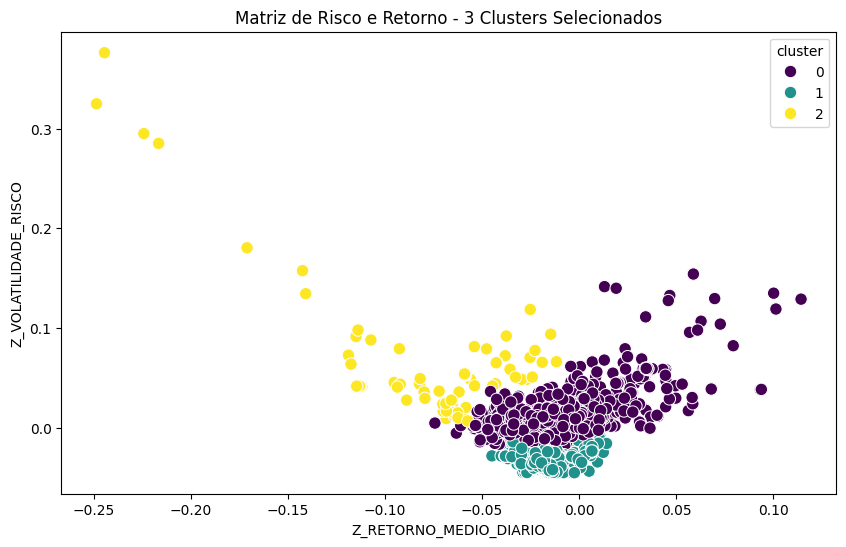

In [81]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt


cluster_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df_limpo['cluster'] = cluster_model.fit_predict(df_limpo[z_variaveis])

# Gerando o gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpo, x=z_variaveis[0], y=z_variaveis[1], hue='cluster', palette='viridis', s=80)
plt.title('Matriz de Risco e Retorno - 3 Clusters Selecionados')
plt.show()

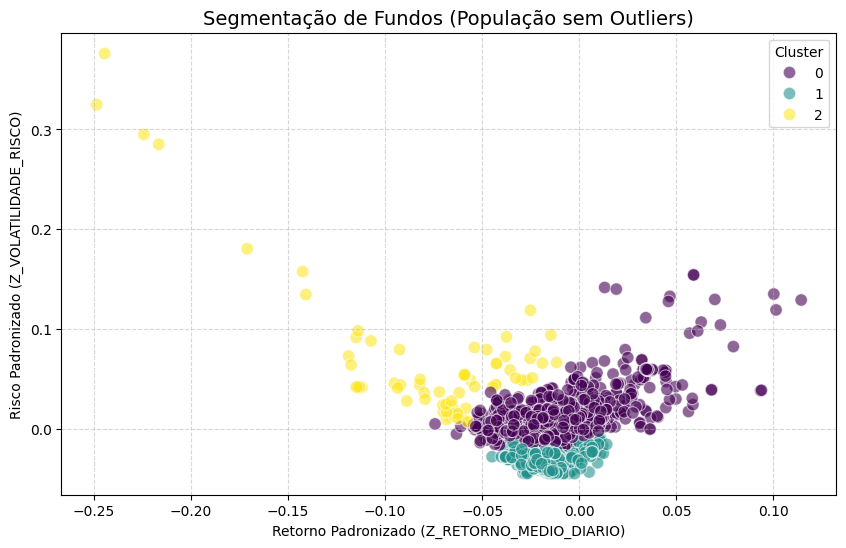

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurando o estilo do gráfico
plt.figure(figsize=(10, 6))


# Usando as colunas Z_
sns.scatterplot(
    data=df_limpo,
    x=z_variaveis[0],
    y=z_variaveis[1],
    hue='cluster',
    palette='viridis',
    s=80,
    alpha=0.6
)

plt.title('Segmentação de Fundos (População sem Outliers)', fontsize=14)
plt.xlabel(f'Retorno Padronizado ({z_variaveis[0]})')
plt.ylabel(f'Risco Padronizado ({z_variaveis[1]})')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

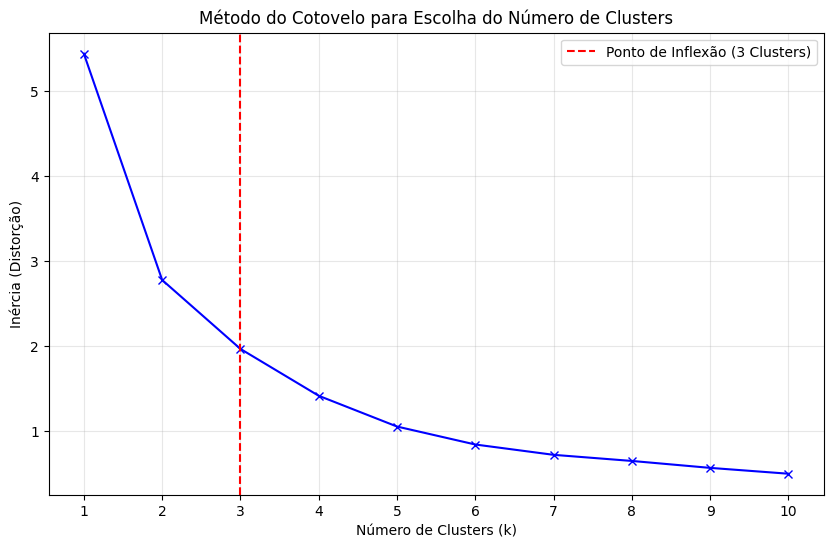

In [83]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Calculando a 'Inércia' (Soma dos quadrados dentro dos clusters)
# Testamos de 1 a 10 grupos para ver onde o ganho de informação diminui
distorcoes = []
K = range(1, 11)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(df_limpo[z_variaveis])
    distorcoes.append(kmeanModel.inertia_)

# 2. Gerando o Gráfico do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(K, distorcoes, 'bx-') # Linha azul com marcadores em X
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Distorção)')
plt.title('Método do Cotovelo para Escolha do Número de Clusters')
plt.xticks(K) # Garante que todos os números de 1 a 10 apareçam no eixo X

# Destacando o ponto 3 (seu objetivo)
plt.axvline(x=3, color='red', linestyle='--', label='Ponto de Inflexão (3 Clusters)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [84]:
from sklearn.metrics import silhouette_score

# Calcula o score médio para os 3 clusters
score = silhouette_score(df_limpo[z_variaveis], df_limpo['cluster'])

print(f"Coeficiente de Silhouette Médio: {score:.4f}")

# Interpretação rápida:
if score > 0.5:
    print("✅ Excelente separação e coesão!")
elif score > 0.25:
    print("🟡 Estrutura razoável, mas há alguma sobreposição.")
else:
    print("🔴 Os clusters estão muito misturados ou a amostra é muito dispersa.")

Coeficiente de Silhouette Médio: 0.6222
✅ Excelente separação e coesão!


Resultados não foram satisfatorios